<a href="https://colab.research.google.com/github/Shamima21/TumorPhylogenyLearning/blob/main/Metastasis__Learning_Conserved_Evolutionary_Patterns_in_Cancer_from_Tumour_Phylogenies_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ============================================================
# METASTASIS DATA: INITIAL INSPECTION
# ============================================================

mets <- readRDS(
  "/content/sample_data/20221108_mets_seeding_combined_variables_df_cruk.RDS"
)

patient_data <- readRDS(
  "/content/sample_data/20221109_TRACERx421_all_patient_df.rds"
)

lung_rec <- readRDS(
  "/content/sample_data/20221108_lung_rec_df.RDS"
)


cat("===== METASTASIS DATA =====\n")
print(dim(mets))
print(names(mets))
print(head(mets))
str(mets)

cat("\n===== PATIENT DATA =====\n")
print(dim(patient_data))
print(names(patient_data))
print(head(patient_data))
str(patient_data)

cat("\n===== LUNG RECURRENCE DATA =====\n")
print(dim(lung_rec))
print(names(lung_rec))
print(head(lung_rec))
str(lung_rec)

===== METASTASIS DATA =====
[1] 436  13
 [1] "mets_sample"            "regions"                "mets_pattern"          
 [4] "mets_grade"             "mets_grade.num"         "primary_pattern_all"   
 [7] "primary_grade_all"      "primary_grade.num_mean" "organ_mets"            
[10] "timing"                 "timing_detail"          "tumour_id"             
[13] "cruk_id"               
        mets_sample regions mets_pattern mets_grade mets_grade.num
1 CRUK0090_BP_T1_R1 seeding           NA       n.a.             NA
2 CRUK0090_BR_T1_R1 seeding           NA       n.a.             NA
3 CRUK0090_BP_T2_R1 seeding           NA       n.a.             NA
4 CRUK0063_BR_T1_R1 seeding           NA       n.a.             NA
5     CRUK0063_FLN1 seeding           NA       n.a.             NA
6     CRUK0092_FLN1 seeding           NA       n.a.             NA
       primary_pattern_all        primary_grade_all primary_grade.num_mean
1                n.a.;n.a.                n.a.;n.a.               

In [6]:
# ============================================================
# STEP 3: INSPECT CLINICAL / METASTASIS OUTCOME CATEGORIES
# ============================================================

cat("===== RELAPSE CATEGORIES =====\n")
print(levels(patient_data$Relapse_cat_new))
print(table(patient_data$Relapse_cat_new, useNA = "ifany"))

cat("\n===== FIRST EVENT =====\n")
print(table(
  patient_data$first_event_during_followup,
  useNA = "ifany"
))

cat("\n===== RECURRENCE EVENT =====\n")
print(table(
  patient_data$first_dfs_any_event_rec.or.new.primary,
  useNA = "ifany"
))

cat("\n===== METASTASIS TIMING =====\n")
print(table(mets$timing, useNA = "ifany"))

cat("\n===== METASTASIS TIMING DETAIL =====\n")
print(table(mets$timing_detail, useNA = "ifany"))

cat("\n===== METASTATIC ORGANS =====\n")
print(
  sort(
    table(mets$organ_mets, useNA = "ifany"),
    decreasing = TRUE
  )
)

cat("\n===== NUMBER OF UNIQUE PATIENTS IN METASTASIS DATA =====\n")
print(length(unique(mets$cruk_id)))

===== RELAPSE CATEGORIES =====
[1] "No rec"        "Intrathoracic" "Intra & Extra" "Extrathoracic"
[5] "Unknown Site" 

       No rec Intrathoracic Intra & Extra Extrathoracic  Unknown Site 
          279            61            43            34             4 

===== FIRST EVENT =====

             Death        new_primary         recurrence recurrence (death) 
                42                 41                139                  3 
              <NA> 
               196 

===== RECURRENCE EVENT =====

new_primary  recurrence        <NA> 
         41         142         238 

===== METASTASIS TIMING =====

Primary Post-op 
    302     134 

===== METASTASIS TIMING DETAIL =====

    Primary     Relapse Progression 
        302         116          18 

===== METASTATIC ORGANS =====

  lymphnode        lung       brain        bone       liver        skin 
        348          30          12          10           8           6 
 peritoneal      pleura soft_tissue       stump     adre

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppEigen’, ‘BH’, ‘sitmo’, ‘FNN’, ‘irlba’, ‘RcppAnnoy’, ‘RSpectra’, ‘dqrng’, ‘RcppProgress’




INPUT DATA
Patients / tumour phylogenies: 398 
Columns: 26 

FINAL SIX-FEATURE MATRIX
Patients: 398 
Features: 6 
[1] "n_terminal"              "max_depth"              
[3] "total_mutations"         "trunk_mutation_fraction"
[5] "mean_branch_mutations"   "first_branching_depth"  

Missing values before imputation: 21 
Missing values after imputation: 0 

Scaled feature matrix: 398 patients x 6 features

SILHOUETTE ANALYSIS
   k average_silhouette
1  2          0.2408694
2  3          0.2550279
3  4          0.2442572
4  5          0.2169240
5  6          0.2157078
6  7          0.2049415
7  8          0.2025418
8  9          0.2103902
9 10          0.2148175

Optimal k: 3 

FINAL K-MEANS CLUSTER SIZES
cluster_kmeans
  1   2   3 
 62 161 175 

First cluster assignments:
   patient_id  cruk_id cluster
1    CRUK0005 CRUK0005       2
2    CRUK0057 CRUK0057       3
3    CRUK0039 CRUK0039       3
4    CRUK0196 CRUK0196       3
5    CRUK0023 CRUK0023       3
6    CRUK0050 CRUK0050       1
7 

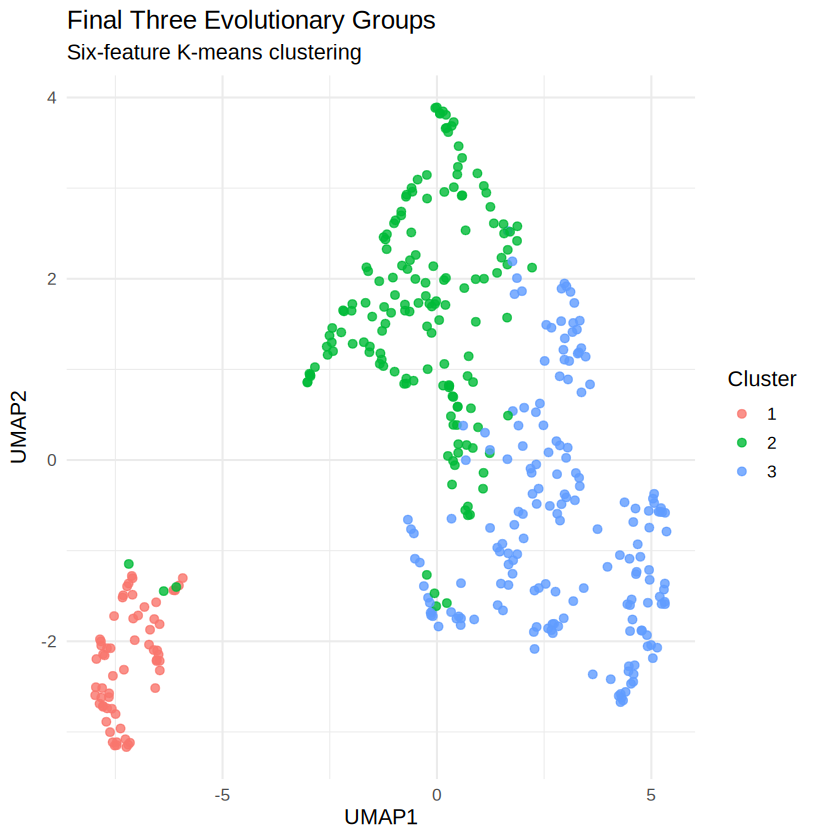

In [7]:
# ============================================================
# ONE-CELL FINAL CLUSTERING FOR NEW NOTEBOOK
# Input:
# TRACERx421_patient_level_evolutionary_feature_matrix.csv
#
# Output:
# TRACERx_final_cluster_assignments.csv
# ============================================================

# ------------------------------------------------------------
# 0. INSTALL / LOAD PACKAGES
# ------------------------------------------------------------

packages <- c(
  "dplyr",
  "ggplot2",
  "cluster",
  "uwot",
  "stringr"
)

new_packages <- packages[
  !(packages %in% rownames(installed.packages()))
]

if (length(new_packages) > 0) {
  install.packages(new_packages)
}

suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(cluster)
  library(uwot)
  library(stringr)
})

set.seed(42)


# ============================================================
# 1. LOAD THE 398-PHYLOGENY FEATURE MATRIX
# ============================================================

feature_file <-
  "/content/sample_data/TRACERx421_patient_level_evolutionary_feature_matrix.csv"

stopifnot(file.exists(feature_file))

patient_level_feature_matrix <-
  read.csv(
    feature_file,
    stringsAsFactors = FALSE,
    check.names = FALSE
  )

cat("========================================\n")
cat("INPUT DATA\n")
cat("========================================\n")

cat(
  "Patients / tumour phylogenies:",
  nrow(patient_level_feature_matrix),
  "\n"
)

cat(
  "Columns:",
  ncol(patient_level_feature_matrix),
  "\n\n"
)


# ============================================================
# 2. FINAL SIX EVOLUTIONARY FEATURES
# ============================================================

final_selected_features <- c(
  "n_terminal",
  "max_depth",
  "total_mutations",
  "trunk_mutation_fraction",
  "mean_branch_mutations",
  "first_branching_depth"
)

missing_features <- setdiff(
  final_selected_features,
  colnames(patient_level_feature_matrix)
)

if (length(missing_features) > 0) {
  stop(
    paste(
      "Missing features:",
      paste(missing_features, collapse = ", ")
    )
  )
}

final_data <- patient_level_feature_matrix %>%
  select(
    patient_id,
    all_of(final_selected_features)
  )

cat("========================================\n")
cat("FINAL SIX-FEATURE MATRIX\n")
cat("========================================\n")

cat("Patients:", nrow(final_data), "\n")
cat("Features:", length(final_selected_features), "\n")

print(final_selected_features)


# ============================================================
# 3. HANDLE Inf / -Inf / MISSING VALUES
# ============================================================

X <- final_data %>%
  select(-patient_id)

X[] <- lapply(
  X,
  function(x) {

    x[is.infinite(x)] <- NA

    x
  }
)

cat(
  "\nMissing values before imputation:",
  sum(is.na(X)),
  "\n"
)

# Median imputation
X[] <- lapply(
  X,
  function(x) {

    if (any(is.na(x))) {

      x[is.na(x)] <-
        median(
          x,
          na.rm = TRUE
        )
    }

    x
  }
)

cat(
  "Missing values after imputation:",
  sum(is.na(X)),
  "\n"
)


# ============================================================
# 4. TRANSFORM MUTATION-BURDEN FEATURES
# ============================================================

X_transformed <- X

X_transformed$total_mutations <-
  log1p(
    X_transformed$total_mutations
  )

X_transformed$mean_branch_mutations <-
  log1p(
    X_transformed$mean_branch_mutations
  )


# ============================================================
# 5. Z-SCORE STANDARDIZATION
# ============================================================

scaled_features <-
  scale(X_transformed)

scaled_features <-
  as.data.frame(scaled_features)

rownames(scaled_features) <-
  final_data$patient_id

cat(
  "\nScaled feature matrix:",
  nrow(scaled_features),
  "patients x",
  ncol(scaled_features),
  "features\n"
)


# ============================================================
# 6. SILHOUETTE ANALYSIS, k = 2:10
# ============================================================

patient_dist <-
  dist(
    scaled_features,
    method = "euclidean"
  )

silhouette_results <-
  data.frame(
    k = 2:10,
    average_silhouette = NA_real_
  )

for (k in 2:10) {

  set.seed(42)

  km_temp <-
    kmeans(
      scaled_features,
      centers = k,
      nstart = 500,
      iter.max = 1000
    )

  sil_temp <-
    silhouette(
      km_temp$cluster,
      patient_dist
    )

  silhouette_results$average_silhouette[
    silhouette_results$k == k
  ] <- mean(
    sil_temp[, 3]
  )
}

optimal_k <-
  silhouette_results$k[
    which.max(
      silhouette_results$average_silhouette
    )
  ]

cat("\n========================================\n")
cat("SILHOUETTE ANALYSIS\n")
cat("========================================\n")

print(silhouette_results)

cat(
  "\nOptimal k:",
  optimal_k,
  "\n"
)


# ============================================================
# 7. FINAL K-MEANS CLUSTERING
# ============================================================

k_final <- 3

set.seed(42)

kmeans_result <-
  kmeans(
    scaled_features,
    centers = k_final,
    nstart = 500,
    iter.max = 1000
  )

cluster_kmeans <-
  kmeans_result$cluster

cat("\n========================================\n")
cat("FINAL K-MEANS CLUSTER SIZES\n")
cat("========================================\n")

print(
  table(cluster_kmeans)
)


# ============================================================
# 8. CREATE PATIENT / TREE CLUSTER TABLE
# ============================================================

cluster_df <- data.frame(

  patient_id =
    final_data$patient_id,

  cruk_id =
    str_extract(
      toupper(final_data$patient_id),
      "CRUK[0-9]+"
    ),

  cluster =
    as.integer(cluster_kmeans),

  stringsAsFactors = FALSE
)

cat("\nFirst cluster assignments:\n")

print(
  head(
    cluster_df,
    10
  )
)


# ============================================================
# 9. UMAP COORDINATES
# useful later for metastasis overlay
# ============================================================

set.seed(42)

umap_result <-
  uwot::umap(
    scaled_features,
    n_neighbors = 15,
    min_dist = 0.1,
    metric = "euclidean",
    n_components = 2,
    verbose = FALSE
  )

cluster_df$UMAP1 <-
  umap_result[, 1]

cluster_df$UMAP2 <-
  umap_result[, 2]


# ============================================================
# 10. ADD ORIGINAL SIX FEATURES
# ============================================================

cluster_df <-
  cluster_df %>%
  left_join(
    final_data,
    by = "patient_id"
  )


# ============================================================
# 11. SAVE FINAL CLUSTER TABLE
# ============================================================

write.csv(
  cluster_df,
  "/content/TRACERx_final_cluster_assignments.csv",
  row.names = FALSE
)

cat("\n========================================\n")
cat("DONE\n")
cat("========================================\n")

cat(
  "Saved:",
  "/content/TRACERx_final_cluster_assignments.csv",
  "\n"
)

cat(
  "Unique CRUK IDs:",
  length(unique(cluster_df$cruk_id)),
  "\n"
)


# ============================================================
# 12. SIMPLE UMAP CHECK
# ============================================================

p <- ggplot(
  cluster_df,
  aes(
    x = UMAP1,
    y = UMAP2,
    color = factor(cluster)
  )
) +
  geom_point(
    size = 2,
    alpha = 0.8
  ) +
  labs(
    title = "Final Three Evolutionary Groups",
    subtitle = "Six-feature K-means clustering",
    color = "Cluster"
  ) +
  theme_minimal(
    base_size = 13
  )

print(p)

In [8]:
# ============================================================
# CELL 4: CHECK MULTIPLE TREES PER PATIENT
# ============================================================

library(dplyr)

# How many trees per CRUK patient?
duplicate_check <- cluster_df %>%
  group_by(cruk_id) %>%
  summarise(
    n_trees = n(),
    n_clusters = n_distinct(cluster),
    clusters = paste(sort(unique(cluster)), collapse = ", "),
    tree_ids = paste(patient_id, collapse = "; "),
    .groups = "drop"
  ) %>%
  filter(n_trees > 1)

cat("========================================\n")
cat("PATIENTS WITH MULTIPLE PHYLOGENIES\n")
cat("========================================\n")

print(duplicate_check)

cat(
  "\nNumber of patients with multiple trees:",
  nrow(duplicate_check),
  "\n"
)

# Patients whose multiple trees were assigned
# to DIFFERENT clusters
conflict_patients <- duplicate_check %>%
  filter(n_clusters > 1)

cat("\n========================================\n")
cat("PATIENTS WITH CLUSTER CONFLICT\n")
cat("========================================\n")

print(conflict_patients)

cat(
  "\nNumber of patients with conflicting cluster assignments:",
  nrow(conflict_patients),
  "\n"
)

PATIENTS WITH MULTIPLE PHYLOGENIES
# A tibble: 8 × 5
  cruk_id  n_trees n_clusters clusters tree_ids                                 
  <chr>      <int>      <int> <chr>    <chr>                                    
1 CRUK0223       2          2 2, 3     CRUK0223_Tumour1; CRUK0223_Tumour2       
2 CRUK0372       2          2 1, 3     CRUK0372_Tumour1; CRUK0372_Tumour2       
3 CRUK0555       2          1 3        CRUK0555_Tumour1; CRUK0555_Tumour2       
4 CRUK0586       2          2 2, 3     CRUK0586_Tumour1; CRUK0586_Tumour2       
5 CRUK0620       2          1 2        CRUK0620_Tumour1; CRUK0620_Tumour2       
6 CRUK0704       3          2 1, 2     CRUK0704_Tumour1; CRUK0704_Tumour2; CRUK…
7 CRUK0721       2          1 3        CRUK0721_Tumour1; CRUK0721_Tumour2       
8 CRUK0881       2          2 2, 3     CRUK0881_Tumour1; CRUK0881_Tumour2       

Number of patients with multiple trees: 8 

PATIENTS WITH CLUSTER CONFLICT
# A tibble: 5 × 5
  cruk_id  n_trees n_clusters clusters tree

In [9]:
# ============================================================
# CELL 5: CREATE CLEAN PATIENT-LEVEL CLUSTER COHORT
# ============================================================

library(dplyr)

# ------------------------------------------------------------
# 1. Identify patients with conflicting cluster assignments
# ------------------------------------------------------------

conflict_ids <- cluster_df %>%
  group_by(cruk_id) %>%
  summarise(
    n_clusters = n_distinct(cluster),
    .groups = "drop"
  ) %>%
  filter(n_clusters > 1) %>%
  pull(cruk_id)

cat("Patients with conflicting cluster assignments:\n")
print(conflict_ids)

cat(
  "\nNumber of conflicting patients:",
  length(conflict_ids),
  "\n"
)


# ------------------------------------------------------------
# 2. Remove conflicting patients
# ------------------------------------------------------------

cluster_no_conflict <- cluster_df %>%
  filter(
    !(cruk_id %in% conflict_ids)
  )


# ------------------------------------------------------------
# 3. Collapse multiple trees that belong to SAME cluster
#    -> one row per CRUK patient
# ------------------------------------------------------------

patient_cluster_clean <- cluster_no_conflict %>%
  group_by(cruk_id) %>%
  summarise(
    cluster = first(cluster),
    n_trees = n(),
    tree_ids = paste(
      patient_id,
      collapse = "; "
    ),
    .groups = "drop"
  )


# ------------------------------------------------------------
# 4. CHECK
# ------------------------------------------------------------

cat("\n========================================\n")
cat("CLEAN PATIENT-LEVEL CLUSTER COHORT\n")
cat("========================================\n")

cat(
  "Original phylogenies:",
  nrow(cluster_df),
  "\n"
)

cat(
  "Original unique patients:",
  n_distinct(cluster_df$cruk_id),
  "\n"
)

cat(
  "Excluded conflicting patients:",
  length(conflict_ids),
  "\n"
)

cat(
  "Final unambiguous patients:",
  nrow(patient_cluster_clean),
  "\n"
)

cat("\nCluster sizes after patient-level cleaning:\n")

print(
  table(patient_cluster_clean$cluster)
)


# Check: exactly one row per patient
cat(
  "\nDuplicated CRUK IDs remaining:",
  sum(duplicated(patient_cluster_clean$cruk_id)),
  "\n"
)


# ------------------------------------------------------------
# 5. Patients collapsed from >1 tree
# ------------------------------------------------------------

cat("\nPatients retained with multiple trees in same cluster:\n")

print(
  patient_cluster_clean %>%
    filter(n_trees > 1)
)


# ------------------------------------------------------------
# 6. Save clean cohort
# ------------------------------------------------------------

write.csv(
  patient_cluster_clean,
  "/content/TRACERx_clean_patient_cluster_assignments.csv",
  row.names = FALSE
)

cat(
  "\nSaved: TRACERx_clean_patient_cluster_assignments.csv\n"
)

Patients with conflicting cluster assignments:
[1] "CRUK0223" "CRUK0372" "CRUK0586" "CRUK0704" "CRUK0881"

Number of conflicting patients: 5 

CLEAN PATIENT-LEVEL CLUSTER COHORT
Original phylogenies: 398 
Original unique patients: 389 
Excluded conflicting patients: 5 
Final unambiguous patients: 384 

Cluster sizes after patient-level cleaning:

  1   2   3 
 59 156 169 

Duplicated CRUK IDs remaining: 0 

Patients retained with multiple trees in same cluster:
# A tibble: 3 × 4
  cruk_id  cluster n_trees tree_ids                          
  <chr>      <int>   <int> <chr>                             
1 CRUK0555       3       2 CRUK0555_Tumour1; CRUK0555_Tumour2
2 CRUK0620       2       2 CRUK0620_Tumour1; CRUK0620_Tumour2
3 CRUK0721       3       2 CRUK0721_Tumour1; CRUK0721_Tumour2

Saved: TRACERx_clean_patient_cluster_assignments.csv


In [10]:
# ============================================================
# CELL 6
# CREATE MASTER PATIENT-LEVEL DATASET
#
# 384 clean patients
# + clinical information
# + metastasis information
# ============================================================

library(dplyr)

# ============================================================
# 1. CHECK REQUIRED OBJECTS
# ============================================================

stopifnot(exists("patient_cluster_clean"))
stopifnot(exists("patient_data"))
stopifnot(exists("mets"))
stopifnot(exists("lung_rec"))

cat("========================================\n")
cat("INPUT DATA\n")
cat("========================================\n")

cat(
  "Clean clustered patients:",
  nrow(patient_cluster_clean),
  "\n"
)

cat(
  "Clinical patients:",
  nrow(patient_data),
  "\n"
)

cat(
  "Metastasis sample rows:",
  nrow(mets),
  "\n"
)


# ============================================================
# 2. COLLAPSE METASTASIS DATA
#    436 sample rows -> one row per CRUK patient
# ============================================================

mets_patient <- mets %>%
  group_by(cruk_id) %>%
  summarise(

    # number of metastatic/seeding samples
    n_met_samples = n(),

    # metastatic organs
    n_met_organs =
      n_distinct(
        organ_mets[!is.na(organ_mets)]
      ),

    metastatic_organs =
      paste(
        sort(
          unique(
            as.character(
              organ_mets[!is.na(organ_mets)]
            )
          )
        ),
        collapse = "; "
      ),

    # timing
    any_primary =
      any(
        timing == "Primary",
        na.rm = TRUE
      ),

    any_postop =
      any(
        timing == "Post-op",
        na.rm = TRUE
      ),

    # detailed timing
    any_relapse =
      any(
        timing_detail == "Relapse",
        na.rm = TRUE
      ),

    any_progression =
      any(
        timing_detail == "Progression",
        na.rm = TRUE
      ),

    .groups = "drop"
  )


cat("\n========================================\n")
cat("PATIENT-LEVEL METASTASIS DATA\n")
cat("========================================\n")

cat(
  "Unique patients represented in mets:",
  nrow(mets_patient),
  "\n"
)

print(
  head(mets_patient, 10)
)


# ============================================================
# 3. PREPARE CLINICAL DATA
# ============================================================

clinical_selected <- patient_data %>%
  select(
    cruk_id,

    # demographic
    age,
    sex,

    # tumour / disease characteristics
    pathologyTNM,
    pT_stage_per_patient,
    pN_stage_per_patient,
    histology_multi_full_genomically.confirmed,

    # recurrence
    Recurrence_time_use,
    first_dfs_any_event_rec.or.new.primary,
    first_event_during_followup,
    Relapse_cat,
    Relapse_cat_new,

    # survival
    cens_os,
    os_time,
    cens_dfs,
    dfs_time
  )


# ============================================================
# 4. MERGE CLUSTERS WITH CLINICAL DATA
# ============================================================

analysis_master <- patient_cluster_clean %>%

  left_join(
    clinical_selected,
    by = "cruk_id"
  ) %>%

  left_join(
    mets_patient,
    by = "cruk_id"
  )


# ============================================================
# 5. ADD INDICATOR FOR PRESENCE IN METASTASIS DATASET
#
# IMPORTANT:
# This means the patient appears in the mets dataset.
# Do NOT yet interpret absence as biologically non-metastatic.
# ============================================================

analysis_master <- analysis_master %>%
  mutate(

    mets_data_available =
      ifelse(
        cruk_id %in% mets_patient$cruk_id,
        "Yes",
        "No"
      ),

    cluster =
      factor(
        cluster,
        levels = c(1, 2, 3)
      )
  )


# ============================================================
# 6. CHECK MERGE
# ============================================================

cat("\n========================================\n")
cat("MERGE SUMMARY\n")
cat("========================================\n")

cat(
  "Final master rows:",
  nrow(analysis_master),
  "\n"
)

cat(
  "Unique patients:",
  n_distinct(analysis_master$cruk_id),
  "\n"
)

cat(
  "Duplicated patient IDs:",
  sum(duplicated(analysis_master$cruk_id)),
  "\n"
)

cat(
  "Patients without clinical match:",
  sum(is.na(analysis_master$age)),
  "\n"
)


# ============================================================
# 7. CLUSTER SIZES
# ============================================================

cat("\n========================================\n")
cat("CLUSTERS\n")
cat("========================================\n")

print(
  table(
    analysis_master$cluster,
    useNA = "ifany"
  )
)


# ============================================================
# 8. EXACT RELAPSE CATEGORIES
# ============================================================

cat("\n========================================\n")
cat("RELAPSE CATEGORY LEVELS\n")
cat("========================================\n")

print(
  levels(
    droplevels(
      analysis_master$Relapse_cat_new
    )
  )
)

cat("\nRelapse category counts:\n")

print(
  table(
    analysis_master$Relapse_cat_new,
    useNA = "ifany"
  )
)


# ============================================================
# 9. RELAPSE CATEGORY BY EVOLUTIONARY CLUSTER
# ============================================================

cat("\n========================================\n")
cat("RELAPSE CATEGORY BY CLUSTER\n")
cat("========================================\n")

print(
  table(
    analysis_master$cluster,
    analysis_master$Relapse_cat_new,
    useNA = "ifany"
  )
)


# ============================================================
# 10. PATIENTS PRESENT IN METASTASIS DATA
# ============================================================

cat("\n========================================\n")
cat("METASTASIS DATA AVAILABILITY\n")
cat("========================================\n")

print(
  table(
    analysis_master$mets_data_available
  )
)

cat("\nBy cluster:\n")

print(
  table(
    analysis_master$cluster,
    analysis_master$mets_data_available
  )
)


# ============================================================
# 11. METASTASIS TIMING AMONG MATCHED PATIENTS
# ============================================================

cat("\n========================================\n")
cat("METASTASIS TIMING AMONG MATCHED PATIENTS\n")
cat("========================================\n")

cat("\nPrimary:\n")
print(
  table(
    analysis_master$cluster,
    analysis_master$any_primary,
    useNA = "ifany"
  )
)

cat("\nPost-operative:\n")
print(
  table(
    analysis_master$cluster,
    analysis_master$any_postop,
    useNA = "ifany"
  )
)

cat("\nRelapse:\n")
print(
  table(
    analysis_master$cluster,
    analysis_master$any_relapse,
    useNA = "ifany"
  )
)

cat("\nProgression:\n")
print(
  table(
    analysis_master$cluster,
    analysis_master$any_progression,
    useNA = "ifany"
  )
)


# ============================================================
# 12. SAVE MASTER DATASET
# ============================================================

write.csv(
  analysis_master,
  "/content/TRACERx_cluster_clinical_metastasis_master.csv",
  row.names = FALSE
)

cat("\n========================================\n")
cat("DONE\n")
cat("========================================\n")

cat(
  "Saved: TRACERx_cluster_clinical_metastasis_master.csv\n"
)

INPUT DATA
Clean clustered patients: 384 
Clinical patients: 421 
Metastasis sample rows: 436 

PATIENT-LEVEL METASTASIS DATA
Unique patients represented in mets: 126 
# A tibble: 10 × 8
   cruk_id  n_met_samples n_met_organs metastatic_organs any_primary any_postop
   <chr>            <int>        <int> <chr>             <lgl>       <lgl>     
 1 CRUK0003             2            1 lymphnode         TRUE        FALSE     
 2 CRUK0004             2            1 lymphnode         FALSE       TRUE      
 3 CRUK0009             2            1 lymphnode         TRUE        FALSE     
 4 CRUK0010             8            2 lung; lymphnode   TRUE        TRUE      
 5 CRUK0013             8            1 lymphnode         TRUE        FALSE     
 6 CRUK0022             2            1 lymphnode         TRUE        FALSE     
 7 CRUK0027             2            1 lymphnode         TRUE        FALSE     
 8 CRUK0029             8            2 brain; lymphnode  TRUE        TRUE      
 9 CRUK0035  

RECURRENCE / METASTASIS PHENOTYPE

            No recurrence  Intrathoracic recurrence Extrathoracic involvement 
                      252                        56                        73 
                     <NA> 
                        3 

CLUSTER x RECURRENCE PATTERN
   
    No recurrence Intrathoracic recurrence Extrathoracic involvement
  1            42                        8                         8
  2           104                       22                        29
  3           106                       26                        36

WITHIN-CLUSTER PERCENTAGES (%)
   
    No recurrence Intrathoracic recurrence Extrathoracic involvement
  1         72.41                    13.79                     13.79
  2         67.10                    14.19                     18.71
  3         63.10                    15.48                     21.43

CHI-SQUARE TEST

	Pearson's Chi-squared test

data:  association_table
X-squared = 2.07, df = 4, p-value = 0.7229


Expected count

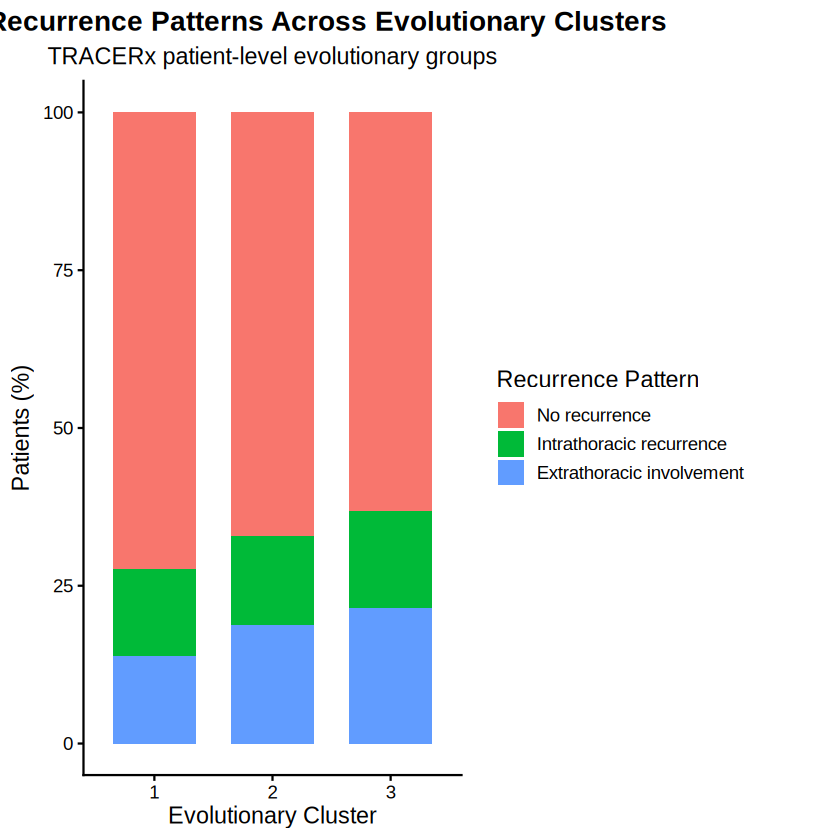

In [11]:
# ============================================================
# CELL 7
# ASSOCIATION BETWEEN EVOLUTIONARY CLUSTER
# AND METASTATIC / RECURRENCE PATTERN
# ============================================================

library(dplyr)
library(ggplot2)

# ============================================================
# 1. DEFINE CLINICAL RECURRENCE PHENOTYPE
# ============================================================

analysis_clinical <- analysis_master %>%
  mutate(

    recurrence_pattern = case_when(

      Relapse_cat_new == "No rec" ~
        "No recurrence",

      Relapse_cat_new == "Intrathoracic" ~
        "Intrathoracic recurrence",

      Relapse_cat_new %in% c(
        "Intra & Extra",
        "Extrathoracic"
      ) ~
        "Extrathoracic involvement",

      TRUE ~ NA_character_
    ),

    recurrence_pattern = factor(
      recurrence_pattern,
      levels = c(
        "No recurrence",
        "Intrathoracic recurrence",
        "Extrathoracic involvement"
      )
    )
  )


# ============================================================
# 2. CHECK COUNTS
# ============================================================

cat("========================================\n")
cat("RECURRENCE / METASTASIS PHENOTYPE\n")
cat("========================================\n")

print(
  table(
    analysis_clinical$recurrence_pattern,
    useNA = "ifany"
  )
)


# ============================================================
# 3. CLUSTER x RECURRENCE PATTERN TABLE
# ============================================================

association_table <- table(
  analysis_clinical$cluster,
  analysis_clinical$recurrence_pattern
)

cat("\n========================================\n")
cat("CLUSTER x RECURRENCE PATTERN\n")
cat("========================================\n")

print(association_table)


# ============================================================
# 4. WITHIN-CLUSTER PERCENTAGES
# ============================================================

association_percent <-
  prop.table(
    association_table,
    margin = 1
  ) * 100

cat("\n========================================\n")
cat("WITHIN-CLUSTER PERCENTAGES (%)\n")
cat("========================================\n")

print(
  round(
    association_percent,
    2
  )
)


# ============================================================
# 5. CHI-SQUARE ASSOCIATION TEST
# ============================================================

chi_result <-
  chisq.test(
    association_table
  )

cat("\n========================================\n")
cat("CHI-SQUARE TEST\n")
cat("========================================\n")

print(chi_result)

cat("\nExpected counts:\n")
print(
  round(
    chi_result$expected,
    2
  )
)


# ============================================================
# 6. CRAMER'S V EFFECT SIZE
# ============================================================

n_total <- sum(association_table)

r <- nrow(association_table)
c <- ncol(association_table)

cramers_v <- sqrt(
  as.numeric(chi_result$statistic) /
    (
      n_total *
      min(r - 1, c - 1)
    )
)

cat("\n========================================\n")
cat("EFFECT SIZE\n")
cat("========================================\n")

cat(
  "Cramer's V:",
  round(cramers_v, 3),
  "\n"
)


# ============================================================
# 7. CREATE LONG-FORM DATA FOR FIGURE
# ============================================================

plot_df <- as.data.frame(
  association_table
)

colnames(plot_df) <- c(
  "Cluster",
  "RecurrencePattern",
  "Patients"
)

plot_df <- plot_df %>%
  group_by(Cluster) %>%
  mutate(
    Percentage =
      100 * Patients / sum(Patients)
  ) %>%
  ungroup()


# ============================================================
# 8. STACKED BARPLOT
# ============================================================

p_recurrence <- ggplot(
  plot_df,
  aes(
    x = Cluster,
    y = Percentage,
    fill = RecurrencePattern
  )
) +

  geom_col(
    width = 0.7
  ) +

  labs(
    title =
      "Clinical Recurrence Patterns Across Evolutionary Clusters",

    subtitle =
      "TRACERx patient-level evolutionary groups",

    x =
      "Evolutionary Cluster",

    y =
      "Patients (%)",

    fill =
      "Recurrence Pattern"
  ) +

  theme_classic(
    base_size = 14
  ) +

  theme(
    plot.title =
      element_text(
        face = "bold",
        hjust = 0.5
      ),

    plot.subtitle =
      element_text(
        hjust = 0.5
      )
  )

print(p_recurrence)


# ============================================================
# 9. SAVE FIGURE
# ============================================================

ggsave(
  "/content/Cluster_Recurrence_Metastasis_Association.png",
  p_recurrence,
  width = 8,
  height = 6,
  dpi = 600
)


# ============================================================
# 10. SAVE TABLE
# ============================================================

write.csv(
  plot_df,
  "/content/Cluster_Recurrence_Metastasis_Association.csv",
  row.names = FALSE
)

cat("\nAnalysis complete.\n")

In [14]:
# ============================================================
# CELL 8
# CHARACTERIZE THE MATCHED METASTATIC COHORT
# ============================================================

library(dplyr)

# ------------------------------------------------------------
# 1. KEEP ONLY PATIENTS PRESENT IN METASTASIS DATA
# ------------------------------------------------------------

met_cluster <- analysis_master %>%
  filter(mets_data_available == "Yes")

cat("========================================\n")
cat("MATCHED METASTATIC COHORT\n")
cat("========================================\n")

cat(
  "Patients:",
  nrow(met_cluster),
  "\n"
)

cat("\nPatients by evolutionary cluster:\n")

print(
  table(met_cluster$cluster)
)


# ------------------------------------------------------------
# 2. CREATE MUTUALLY EXCLUSIVE METASTASIS TIMING GROUP
# ------------------------------------------------------------

met_cluster <- met_cluster %>%
  mutate(

    metastasis_timing = case_when(

      any_primary == TRUE &
        any_postop == FALSE ~
        "Primary only",

      any_primary == FALSE &
        any_postop == TRUE ~
        "Post-op only",

      any_primary == TRUE &
        any_postop == TRUE ~
        "Primary and post-op",

      TRUE ~
        "Other"
    ),

    metastasis_timing = factor(
      metastasis_timing,
      levels = c(
        "Primary only",
        "Post-op only",
        "Primary and post-op",
        "Other"
      )
    )
  )


# ------------------------------------------------------------
# 3. METASTASIS TIMING COUNTS
# ------------------------------------------------------------

cat("\n========================================\n")
cat("METASTASIS TIMING\n")
cat("========================================\n")

print(
  table(
    met_cluster$metastasis_timing,
    useNA = "ifany"
  )
)

cat("\nTiming by evolutionary cluster:\n")

timing_table <- table(
  met_cluster$cluster,
  met_cluster$metastasis_timing
)

print(timing_table)


cat("\nWithin-cluster percentages:\n")

print(
  round(
    prop.table(
      timing_table,
      margin = 1
    ) * 100,
    2
  )
)


# ------------------------------------------------------------
# 4. RELAPSE / PROGRESSION STATUS
# ------------------------------------------------------------

cat("\n========================================\n")
cat("RELAPSE AMONG METASTATIC PATIENTS\n")
cat("========================================\n")

print(
  table(
    met_cluster$cluster,
    met_cluster$any_relapse
  )
)


cat("\n========================================\n")
cat("PROGRESSION AMONG METASTATIC PATIENTS\n")
cat("========================================\n")

print(
  table(
    met_cluster$cluster,
    met_cluster$any_progression
  )
)


# ------------------------------------------------------------
# 5. NUMBER OF METASTATIC SAMPLES
# ------------------------------------------------------------

cat("\n========================================\n")
cat("NUMBER OF METASTATIC SAMPLES\n")
cat("========================================\n")

print(
  met_cluster %>%
    group_by(cluster) %>%
    summarise(
      n = n(),
      median_met_samples =
        median(n_met_samples, na.rm = TRUE),
      mean_met_samples =
        mean(n_met_samples, na.rm = TRUE),
      min_met_samples =
        min(n_met_samples, na.rm = TRUE),
      max_met_samples =
        max(n_met_samples, na.rm = TRUE),
      .groups = "drop"
    )
)


# ------------------------------------------------------------
# 6. NUMBER OF METASTATIC ORGANS
# ------------------------------------------------------------

cat("\n========================================\n")
cat("NUMBER OF METASTATIC ORGANS\n")
cat("========================================\n")

print(
  met_cluster %>%
    group_by(cluster) %>%
    summarise(
      n = n(),
      median_met_organs =
        median(n_met_organs, na.rm = TRUE),
      mean_met_organs =
        mean(n_met_organs, na.rm = TRUE),
      min_met_organs =
        min(n_met_organs, na.rm = TRUE),
      max_met_organs =
        max(n_met_organs, na.rm = TRUE),
      .groups = "drop"
    )
)


# ------------------------------------------------------------
# 7. SEE EXACT METASTATIC ORGAN COMBINATIONS
# ------------------------------------------------------------

cat("\n========================================\n")
cat("METASTATIC ORGAN COMBINATIONS\n")
cat("========================================\n")

print(
  sort(
    table(
      met_cluster$metastatic_organs
    ),
    decreasing = TRUE
  )
)


# ------------------------------------------------------------
# 8. SAVE
# ------------------------------------------------------------

write.csv(
  met_cluster,
  "/content/TRACERx_117_matched_metastatic_patients.csv",
  row.names = FALSE
)

cat(
  "\nSaved: TRACERx_117_matched_metastatic_patients.csv\n"
)

MATCHED METASTATIC COHORT
Patients: 117 

Patients by evolutionary cluster:

 1  2  3 
12 55 50 

METASTASIS TIMING

       Primary only        Post-op only Primary and post-op               Other 
                 74                  27                  16                   0 

Timing by evolutionary cluster:
   
    Primary only Post-op only Primary and post-op Other
  1            8            2                   2     0
  2           36           10                   9     0
  3           30           15                   5     0

Within-cluster percentages:
   
    Primary only Post-op only Primary and post-op Other
  1        66.67        16.67               16.67  0.00
  2        65.45        18.18               16.36  0.00
  3        60.00        30.00               10.00  0.00

RELAPSE AMONG METASTATIC PATIENTS
   
    FALSE TRUE
  1     8    4
  2    37   18
  3    30   20

PROGRESSION AMONG METASTATIC PATIENTS
   
    FALSE TRUE
  1    12    0
  2    52    3
  3    49    1



In [15]:
# ============================================================
# CELL 9
# STATISTICAL ASSOCIATION TESTS WITHIN
# THE MATCHED METASTATIC COHORT
# ============================================================

library(dplyr)

cat("========================================\n")
cat("STATISTICAL TESTS: METASTATIC COHORT\n")
cat("========================================\n")


# ============================================================
# 1. METASTASIS TIMING vs CLUSTER
# ============================================================

timing_table <- table(
  met_cluster$cluster,
  met_cluster$metastasis_timing
)

# Remove empty "Other" column
timing_table <- timing_table[
  ,
  colSums(timing_table) > 0,
  drop = FALSE
]

cat("\n1. METASTASIS TIMING vs CLUSTER\n")
print(timing_table)

# Fisher test with Monte-Carlo simulation
set.seed(42)

timing_fisher <- fisher.test(
  timing_table,
  simulate.p.value = TRUE,
  B = 100000
)

print(timing_fisher)


# ============================================================
# 2. RELAPSE vs CLUSTER
# ============================================================

relapse_table <- table(
  met_cluster$cluster,
  met_cluster$any_relapse
)

cat("\n========================================\n")
cat("2. RELAPSE vs CLUSTER\n")
cat("========================================\n")

print(relapse_table)

relapse_fisher <- fisher.test(
  relapse_table
)

print(relapse_fisher)


# ============================================================
# 3. PROGRESSION vs CLUSTER
# ============================================================

progression_table <- table(
  met_cluster$cluster,
  met_cluster$any_progression
)

cat("\n========================================\n")
cat("3. PROGRESSION vs CLUSTER\n")
cat("========================================\n")

print(progression_table)

progression_fisher <- fisher.test(
  progression_table
)

print(progression_fisher)


# ============================================================
# 4. NUMBER OF METASTATIC SAMPLES vs CLUSTER
# ============================================================

cat("\n========================================\n")
cat("4. NUMBER OF METASTATIC SAMPLES\n")
cat("========================================\n")

sample_kw <- kruskal.test(
  n_met_samples ~ cluster,
  data = met_cluster
)

print(sample_kw)


# ============================================================
# 5. NUMBER OF METASTATIC ORGANS vs CLUSTER
# ============================================================

cat("\n========================================\n")
cat("5. NUMBER OF METASTATIC ORGANS\n")
cat("========================================\n")

organ_kw <- kruskal.test(
  n_met_organs ~ cluster,
  data = met_cluster
)

print(organ_kw)


# ============================================================
# 6. SINGLE-ORGAN vs MULTI-ORGAN INVOLVEMENT
# ============================================================

met_cluster <- met_cluster %>%
  mutate(
    organ_spread = ifelse(
      n_met_organs > 1,
      "Multiple organs",
      "Single organ"
    )
  )

organ_spread_table <- table(
  met_cluster$cluster,
  met_cluster$organ_spread
)

cat("\n========================================\n")
cat("6. SINGLE vs MULTIPLE ORGAN INVOLVEMENT\n")
cat("========================================\n")

print(organ_spread_table)

organ_spread_fisher <- fisher.test(
  organ_spread_table
)

print(organ_spread_fisher)


# ============================================================
# 7. LYMPH-NODE-ONLY vs OTHER ORGAN INVOLVEMENT
# ============================================================

met_cluster <- met_cluster %>%
  mutate(
    organ_pattern = ifelse(
      metastatic_organs == "lymphnode",
      "Lymph-node only",
      "Other organ involvement"
    )
  )

organ_pattern_table <- table(
  met_cluster$cluster,
  met_cluster$organ_pattern
)

cat("\n========================================\n")
cat("7. LYMPH-NODE ONLY vs OTHER ORGAN INVOLVEMENT\n")
cat("========================================\n")

print(organ_pattern_table)

organ_pattern_fisher <- fisher.test(
  organ_pattern_table
)

print(organ_pattern_fisher)


# ============================================================
# 8. SUMMARY TABLE OF P-VALUES
# ============================================================

stat_summary <- data.frame(

  Analysis = c(
    "Metastasis timing",
    "Relapse",
    "Progression",
    "Number of metastatic samples",
    "Number of metastatic organs",
    "Single vs multiple organs",
    "Lymph-node only vs other organ"
  ),

  Test = c(
    "Fisher exact",
    "Fisher exact",
    "Fisher exact",
    "Kruskal-Wallis",
    "Kruskal-Wallis",
    "Fisher exact",
    "Fisher exact"
  ),

  P_value = c(
    timing_fisher$p.value,
    relapse_fisher$p.value,
    progression_fisher$p.value,
    sample_kw$p.value,
    organ_kw$p.value,
    organ_spread_fisher$p.value,
    organ_pattern_fisher$p.value
  )
)


# FDR correction
stat_summary$FDR <-
  p.adjust(
    stat_summary$P_value,
    method = "BH"
  )

cat("\n========================================\n")
cat("FINAL STATISTICAL SUMMARY\n")
cat("========================================\n")

print(stat_summary)


# ============================================================
# 9. SAVE
# ============================================================

write.csv(
  stat_summary,
  "/content/Metastatic_Cohort_Statistical_Tests.csv",
  row.names = FALSE
)

cat(
  "\nSaved: Metastatic_Cohort_Statistical_Tests.csv\n"
)

STATISTICAL TESTS: METASTATIC COHORT

1. METASTASIS TIMING vs CLUSTER
   
    Primary only Post-op only Primary and post-op
  1            8            2                   2
  2           36           10                   9
  3           30           15                   5

	Fisher's Exact Test for Count Data with simulated p-value (based on
	1e+05 replicates)

data:  timing_table
p-value = 0.5865
alternative hypothesis: two.sided


2. RELAPSE vs CLUSTER
   
    FALSE TRUE
  1     8    4
  2    37   18
  3    30   20

	Fisher's Exact Test for Count Data

data:  relapse_table
p-value = 0.7573
alternative hypothesis: two.sided


3. PROGRESSION vs CLUSTER
   
    FALSE TRUE
  1    12    0
  2    52    3
  3    49    1

	Fisher's Exact Test for Count Data

data:  progression_table
p-value = 0.7546
alternative hypothesis: two.sided


4. NUMBER OF METASTATIC SAMPLES

	Kruskal-Wallis rank sum test

data:  n_met_samples by cluster
Kruskal-Wallis chi-squared = 1.3069, df = 2, p-value = 0.5203



In [18]:
# ============================================================
# CELL 10: CORRECTED SURVIVAL ANALYSIS
# Evolutionary Clusters vs OS and DFS
# ============================================================

# ------------------------------------------------------------
# 0. PACKAGE
# ------------------------------------------------------------

if (!requireNamespace("survival", quietly = TRUE)) {
  install.packages("survival")
}

library(survival)
library(dplyr)

cat("========================================\n")
cat("SURVIVAL ANALYSIS ACROSS CLUSTERS\n")
cat("========================================\n")


# ============================================================
# 1. PREPARE DATA
# ============================================================

survival_data <- analysis_master %>%
  mutate(
    cluster = factor(
      cluster,
      levels = c(1, 2, 3)
    )
  )


# ------------------------------------------------------------
# Check event coding
# 0 = censored
# 1 = event
# ------------------------------------------------------------

cat("\nOS event codes:\n")
print(table(
  survival_data$cens_os,
  useNA = "ifany"
))

cat("\nDFS event codes:\n")
print(table(
  survival_data$cens_dfs,
  useNA = "ifany"
))


# ============================================================
# 2. OVERALL SURVIVAL DATA
# ============================================================

os_data <- survival_data %>%
  filter(
    !is.na(os_time),
    !is.na(cens_os),
    os_time >= 0
  )

cat("\n========================================\n")
cat("OVERALL SURVIVAL DATA SUMMARY\n")
cat("========================================\n")

os_summary <- os_data %>%
  group_by(cluster) %>%
  summarise(
    patients = n(),
    deaths = sum(cens_os == 1),
    censored = sum(cens_os == 0),
    .groups = "drop"
  )

print(os_summary)


# ============================================================
# 3. KAPLAN-MEIER: OVERALL SURVIVAL
# ============================================================

os_fit <- survfit(
  Surv(os_time, cens_os) ~ cluster,
  data = os_data
)

cat("\n========================================\n")
cat("KAPLAN-MEIER MEDIAN OS\n")
cat("========================================\n")

os_km_table <- as.data.frame(
  summary(os_fit)$table
)

os_km_table$Cluster <- rownames(os_km_table)

os_km_result <- os_km_table %>%
  select(
    Cluster,
    records,
    events,
    median,
    `0.95LCL`,
    `0.95UCL`
  )

print(os_km_result)


# ============================================================
# 4. LOG-RANK TEST: OS
# ============================================================

os_logrank <- survdiff(
  Surv(os_time, cens_os) ~ cluster,
  data = os_data
)

os_df <- length(os_logrank$n) - 1

os_p <- pchisq(
  os_logrank$chisq,
  df = os_df,
  lower.tail = FALSE
)

cat("\n========================================\n")
cat("OVERALL SURVIVAL: LOG-RANK TEST\n")
cat("========================================\n")

print(os_logrank)

cat(
  "\nOS log-rank p-value:",
  os_p,
  "\n"
)


# ============================================================
# 5. UNIVARIATE COX MODEL: OS
# Cluster 1 = reference
# ============================================================

os_cox <- coxph(
  Surv(os_time, cens_os) ~ cluster,
  data = os_data
)

cat("\n========================================\n")
cat("COX MODEL: OVERALL SURVIVAL\n")
cat("========================================\n")

print(
  summary(os_cox)
)


# ============================================================
# 6. PROPORTIONAL HAZARDS ASSUMPTION: OS
# ============================================================

os_ph <- cox.zph(os_cox)

cat("\n========================================\n")
cat("PROPORTIONAL HAZARDS TEST: OS\n")
cat("========================================\n")

print(os_ph)


# ============================================================
# 7. DISEASE-FREE SURVIVAL DATA
# ============================================================

dfs_data <- survival_data %>%
  filter(
    !is.na(dfs_time),
    !is.na(cens_dfs),
    dfs_time >= 0
  )

cat("\n========================================\n")
cat("DISEASE-FREE SURVIVAL DATA SUMMARY\n")
cat("========================================\n")

dfs_summary <- dfs_data %>%
  group_by(cluster) %>%
  summarise(
    patients = n(),
    dfs_events = sum(cens_dfs == 1),
    censored = sum(cens_dfs == 0),
    .groups = "drop"
  )

print(dfs_summary)


# ============================================================
# 8. KAPLAN-MEIER: DFS
# ============================================================

dfs_fit <- survfit(
  Surv(dfs_time, cens_dfs) ~ cluster,
  data = dfs_data
)

cat("\n========================================\n")
cat("KAPLAN-MEIER MEDIAN DFS\n")
cat("========================================\n")

dfs_km_table <- as.data.frame(
  summary(dfs_fit)$table
)

dfs_km_table$Cluster <- rownames(dfs_km_table)

dfs_km_result <- dfs_km_table %>%
  select(
    Cluster,
    records,
    events,
    median,
    `0.95LCL`,
    `0.95UCL`
  )

print(dfs_km_result)


# ============================================================
# 9. LOG-RANK TEST: DFS
# ============================================================

dfs_logrank <- survdiff(
  Surv(dfs_time, cens_dfs) ~ cluster,
  data = dfs_data
)

dfs_df <- length(dfs_logrank$n) - 1

dfs_p <- pchisq(
  dfs_logrank$chisq,
  df = dfs_df,
  lower.tail = FALSE
)

cat("\n========================================\n")
cat("DISEASE-FREE SURVIVAL: LOG-RANK TEST\n")
cat("========================================\n")

print(dfs_logrank)

cat(
  "\nDFS log-rank p-value:",
  dfs_p,
  "\n"
)


# ============================================================
# 10. UNIVARIATE COX MODEL: DFS
# Cluster 1 = reference
# ============================================================

dfs_cox <- coxph(
  Surv(dfs_time, cens_dfs) ~ cluster,
  data = dfs_data
)

cat("\n========================================\n")
cat("COX MODEL: DISEASE-FREE SURVIVAL\n")
cat("========================================\n")

print(
  summary(dfs_cox)
)


# ============================================================
# 11. PROPORTIONAL HAZARDS ASSUMPTION: DFS
# ============================================================

dfs_ph <- cox.zph(dfs_cox)

cat("\n========================================\n")
cat("PROPORTIONAL HAZARDS TEST: DFS\n")
cat("========================================\n")

print(dfs_ph)


# ============================================================
# 12. FINAL SUMMARY
# ============================================================

survival_test_summary <- data.frame(

  Outcome = c(
    "Overall survival",
    "Disease-free survival"
  ),

  Log_rank_chisq = c(
    os_logrank$chisq,
    dfs_logrank$chisq
  ),

  df = c(
    os_df,
    dfs_df
  ),

  P_value = c(
    os_p,
    dfs_p
  )
)

# Correct for the two survival outcomes
survival_test_summary$FDR <- p.adjust(
  survival_test_summary$P_value,
  method = "BH"
)

cat("\n========================================\n")
cat("FINAL SURVIVAL SUMMARY\n")
cat("========================================\n")

print(survival_test_summary)


# ============================================================
# 13. SAVE RESULTS
# ============================================================

write.csv(
  os_summary,
  "/content/OS_Event_Summary.csv",
  row.names = FALSE
)

write.csv(
  os_km_result,
  "/content/OS_KM_Median_Survival.csv",
  row.names = FALSE
)

write.csv(
  dfs_summary,
  "/content/DFS_Event_Summary.csv",
  row.names = FALSE
)

write.csv(
  dfs_km_result,
  "/content/DFS_KM_Median_Survival.csv",
  row.names = FALSE
)

write.csv(
  survival_test_summary,
  "/content/Evolutionary_Clusters_Survival_Tests.csv",
  row.names = FALSE
)

cat("\n========================================\n")
cat("SURVIVAL ANALYSIS COMPLETE\n")
cat("========================================\n")

SURVIVAL ANALYSIS ACROSS CLUSTERS

OS event codes:

  0   1 
222 162 

DFS event codes:

  0   1 
195 189 

OVERALL SURVIVAL DATA SUMMARY
# A tibble: 3 × 4
  cluster patients deaths censored
  <fct>      <int>  <int>    <int>
1 1             59     19       40
2 2            156     68       88
3 3            169     75       94

KAPLAN-MEIER MEDIAN OS
            Cluster records events median 0.95LCL 0.95UCL
cluster=1 cluster=1      59     19   2224      NA      NA
cluster=2 cluster=2     156     68     NA    1339      NA
cluster=3 cluster=3     169     75   2011    1429      NA

OVERALL SURVIVAL: LOG-RANK TEST
Call:
survdiff(formula = Surv(os_time, cens_os) ~ cluster, data = os_data)

            N Observed Expected (O-E)^2/E (O-E)^2/V
cluster=1  59       19     27.6     2.655     3.204
cluster=2 156       68     64.2     0.230     0.381
cluster=3 169       75     70.3     0.316     0.559

 Chisq= 3.2  on 2 degrees of freedom, p= 0.2 

OS log-rank p-value: 0.2012777 

COX MODEL: OVER